In [2]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [3]:

popt_x = [-0.07440003753254729, -1.6573891502891157e-07, 1.1335334893917101e-07, 1.361707542031388e-10, -2.191983865543617e-11, -8.27529140822347e-11, 1.9263176998127947,  6.077687095733269e-07, -4.2086448114737847e-07, -4.985947071388806e-10, 7.847755231694071e-11, 3.0906689146156424e-10, -3.517726711234427, -4.822488104695327e-07, 3.3907124285456263e-07, 3.955138253508527e-10, -6.179849801808017e-11, -2.4995813211918614e-10]

popt_y = [90.00342296310696, 6.120361131439471e-07, -1.1857984583535952e-06, -9.989896869450038e-10, 1.2437464097693772e-09, 3.0415921941992207e-10,-18.758151296953486 -1.449544768196326e-06, 3.556131752230913e-06, 2.938507320557736e-09, -4.300538511720822e-09, -5.8819239055948e-10, -360.8318224469302, 8.83823556695015e-07 -2.4361018510313994e-06, -2.084308181485073e-09, 3.3102742073953914e-09, 1.9405040524868282e-10]

#fit change
popt_x = [0.41379548102284486, -5.8231264268646e-12, -5.974960991138344e-13, 4.2077447766010925e-15, 3.729591447181308e-16, 2.8547076598557194e-16, -0.7647081837962723, -7.409324107802326e-11, -7.607263338824183e-12, 5.354495851719567e-14, 4.747226004468302e-15, 3.635139940912592e-15, -0.2695844954125583, -5.3545580542312986e-11, -5.497805919805721e-12, 3.869582003668951e-14, 3.431085707331075e-15, 2.627517153007814e-15]

popt_y =[0.44894745853286266, -4.464392864945209e-18, 1.9780805707742472e-17, 6.2499274599699345e-21, -3.1203441670924346e-21, -1.5224595636873285e-20, -0.0030196534504350054, 5.317132058107509e-19, -8.268093010840438e-19, -4.758729602773067e-22, 1.35619048317694e-22, 6.2941703978767715e-22, -4.212066908361409e-06, 2.0600301562125372e-21, -4.2405537532552134e-21, -2.059628520604673e-24, 7.288939427829075e-25, 3.2203803762693582e-24]

popt_x = [0.25132304842004705, -7.924348913033894e-10, -7.55572712866082e-11, 5.733568211059955e-13, 4.940363311902182e-14, 3.4780086230422006e-14, -0.8122136564236648, 6.372647114870922e-09, 6.088568958188062e-10, -4.610701395701919e-12, -3.976620042321351e-13, -2.806999784740459e-13, 2.2479230547943554, -1.3125690588411633e-08, -1.2557692778259925e-09, 9.496417441710428e-12, 8.194624239642999e-13, 5.793662971991259e-13, -3.4601615855149195, 7.776606697574711e-09, 7.447440223654857e-10, -5.62627385254284e-12, -4.856873090184157e-13, -3.4377247092041754e-13]

popt_y=[97.10928518170839, 2.956819761024145e-06, -1.121078231155102e-07, -2.2614495893950984e-09, 5.630582399349271e-11, 5.6164511827770195e-11, -78.49998019907623, -2.3179479261602365e-05, 5.824059646861171e-07, 1.7620278047390002e-08, -1.7222995134566124e-10, -3.355385234610857e-10, -235.05338959083105, 4.714212800958263e-05, -1.2070588331963642e-06, -3.579033281954376e-08, 2.4932803521028254e-10, 7.45179401425033e-10, -75.48364077088799, -2.7617884031935824e-05, 7.728680951061682e-07, 2.0941829811949403e-08, -7.377161541019886e-11, -5.285417530588269e-10]

In [4]:
def fit_2D26_2(coords, *vars):
    """
    From niriss_specwcs code:
    https://grit.stsci.edu/NIRISS/reference-file-creation/specwcs/-/blob/main/niriss_specwcs/make_specwcs.py?ref_type=heads#L433
    """
    # Generalized 2D polynomial (2,n) order
    (x,y,t) = coords
    e = vars
    n = len(e)//6
    f = 0
    print('vars',vars)

    for i in range(n):
        #print(i*6,i*6+1,i*6+2,i*6+3,i*6+4,i*6+5)
        f = f + t**i * (e[i*6] + x*e[i*6+1] + y*e[i*6+2] + x**2*e[i*6+3] + x*y*e[i*6+4] + y**2*e[i*6+5])
    return f

In [5]:
tracefile = "/Users/apetric/Desktop/MIRI_WFSS/codes/NewTraceList_20250901.txt"
df = pd.read_csv(tracefile, delimiter=" ")
x = df["X0"].values
y = df["Y0"].values
dx = df["dx"].values
dy = df["dy"].values
lam = df["lam"].values
# Filter the subset
subset = df[(df['X0'] == 849) & (df['Y0'] == 349)]
xpos = subset['X0'] + subset['dx']
ypos = subset['Y0'] + subset['dy']
print(len(xpos))

388


vars (0.25132304842004705, -7.924348913033894e-10, -7.55572712866082e-11, 5.733568211059955e-13, 4.940363311902182e-14, 3.4780086230422006e-14, -0.8122136564236648, 6.372647114870922e-09, 6.088568958188062e-10, -4.610701395701919e-12, -3.976620042321351e-13, -2.806999784740459e-13, 2.2479230547943554, -1.3125690588411633e-08, -1.2557692778259925e-09, 9.496417441710428e-12, 8.194624239642999e-13, 5.793662971991259e-13, -3.4601615855149195, 7.776606697574711e-09, 7.447440223654857e-10, -5.62627385254284e-12, -4.856873090184157e-13, -3.4377247092041754e-13)
388 388


/var/folders/17/zhrqnb9n4_15lxjwctkl20cr0002ld/T/ipykernel_98184/3995511637.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['ts'] = (subset['lam']-3.25)/(14.01-3.25)


(5.0, 14.0)

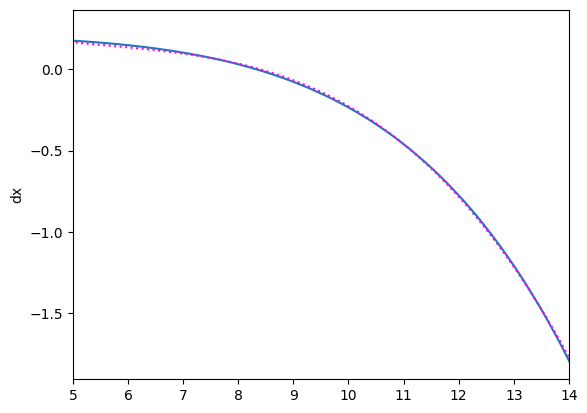

In [23]:
#fig = plt.figure()
#print(popt)
#dy_fit_subset = fit_2D26_2((x, y, dx), *popt)
subset['ts'] = (subset['lam']-3.25)/(14.01-3.25)
result_x = fit_2D26_2((subset["X0"].values, subset["Y0"].values, subset["ts"].values), *popt_x)
print(len(result),len(subset))
#plt.plot(subset['lam'], subset['dy'])
plt.plot(subset['lam'], subset['dx'])
plt.plot(subset['lam'], result_x, ls='dotted', color= 'magenta')
plt.ylabel('dx')
plt.xlim(5,14)

vars (97.10928518170839, 2.956819761024145e-06, -1.121078231155102e-07, -2.2614495893950984e-09, 5.630582399349271e-11, 5.6164511827770195e-11, -78.49998019907623, -2.3179479261602365e-05, 5.824059646861171e-07, 1.7620278047390002e-08, -1.7222995134566124e-10, -3.355385234610857e-10, -235.05338959083105, 4.714212800958263e-05, -1.2070588331963642e-06, -3.579033281954376e-08, 2.4932803521028254e-10, 7.45179401425033e-10, -75.48364077088799, -2.7617884031935824e-05, 7.728680951061682e-07, 2.0941829811949403e-08, -7.377161541019886e-11, -5.285417530588269e-10)
388 388


/var/folders/17/zhrqnb9n4_15lxjwctkl20cr0002ld/T/ipykernel_98184/1720197584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['ts'] = (subset['lam']-3.25)/(14.01-3.25)


(5.0, 14.0)

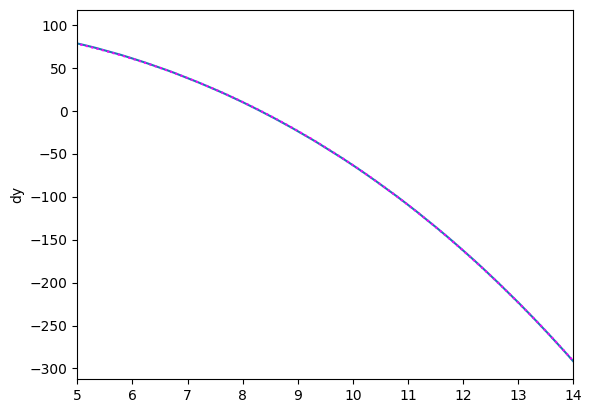

In [24]:
#now look at dy  as a function of wavelenght using popt_y
subset['ts'] = (subset['lam']-3.25)/(14.01-3.25)
result_y = fit_2D26_2((subset["X0"].values, subset["Y0"].values, subset["ts"].values), *popt_y)
print(len(result),len(subset))
#plt.plot(subset['lam'], subset['dy'])
plt.plot(subset['lam'], subset['dy'])
plt.plot(subset['lam'], result_y, ls='dotted', color= 'magenta')
plt.ylabel('dy')
plt.xlim(5,14)

Text(0, 0.5, 'dx')

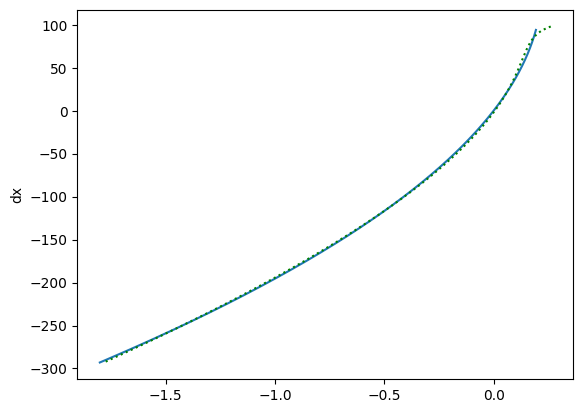

In [26]:
plt.plot(subset['dx'], subset['dy'])
plt.plot(result_x, result_y, ls='dotted', color= 'green')
plt.ylabel('dy')
plt.ylabel('dx')

In [1]:
#fig = plt.figure()
#print(popt)
#dy_fit_subset = fit_2D26_2((x, y, dx), *popt)

xpos = subset['X0'] + subset['dx']

dy_fitted = fit_2D26_2((subset["X0"], subset["Y0"], subset["dx"]), *popt)

line2, = ax1.plot(xpos, dy_fitted, color='green', linewidth=2, label="Modeled dy")

# Plot X0 vs dy on the first y-axis
ax1.plot(xpos, subset['dy'], 'b-', label='dy')
ax1.set_xlabel('X0 + dx')
ax1.set_ylabel('dy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlim(445, 455)


plt.title('X0 + dx vs dy and lam')
fig.tight_layout()
#plt.legend()
plt.show()


NameError: name 'subset' is not defined

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(measured_dy, fitted_dy, s=5)
plt.xlabel("Measured dy")
plt.ylabel("Fitted dy")
plt.plot([measured_dy.min(), measured_dy.max()],
         [measured_dy.min(), measured_dy.max()], 'r--')
plt.title("Measured vs Fitted dy")

# Residuals
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=50)
plt.xlabel("Residual (measured - fitted)")
plt.title("Residuals")

plt.tight_layout()
plt.show()